In [2]:
import pandas as pd
import numpy as np

node_idx = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\NodesIndex.csv')
node_to_idx = dict(zip(node_idx['Node'], node_idx['NodeIndex']))

# Choose an edge type (e.g., Storage Location)
edges = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Edges (Storage Location).csv')

# Convert to indices
edge_index = []
for _, row in edges.iterrows():
    if row['node1'] in node_to_idx and row['node2'] in node_to_idx:
        edge_index.append([node_to_idx[row['node1']], node_to_idx[row['node2']]])

edge_index = np.array(edge_index).T

In [3]:
edge_weight = edges['Storage Location'].values.reshape(-1, 1)

In [5]:
import pandas as pd
import numpy as np

# Load node list (unique product codes)
nodes = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Nodes.csv')
valid_products = set(nodes['Node'])

# Load production data
prod = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Production .csv')
# Drop date column
prod = prod.drop('Date', axis=1)

# Keep only columns that are in the node list
prod = prod[[col for col in prod.columns if col in valid_products]]

# Now check shape: should be (221, 40)
print(prod.shape)  # Expect (221, 40)

# Reshape to (temporal_length, num_nodes, num_features)
node_f = prod.values.T.reshape(221, 40, 1)

(221, 40)


In [6]:
import pandas as pd
import numpy as np

# Load node mapping
node_idx_df = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\NodesIndex.csv')
node_to_idx = dict(zip(node_idx_df['Node'], node_idx_df['NodeIndex']))

# Choose an edge type – for example, "Storage Location"
edges = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Edges (Storage Location).csv')

edge_index = []
edge_weight = []

for _, row in edges.iterrows():
    u = node_to_idx.get(row['node1'])
    v = node_to_idx.get(row['node2'])
    if u is not None and v is not None:
        edge_index.append([u, v])
        edge_weight.append(row['Storage Location'])   # the first column is the weight

edge_index = np.array(edge_index).T      # shape (2, num_edges)
edge_weight = np.array(edge_weight).reshape(-1, 1)   # shape (num_edges, 1)

In [ ]:
import pandas as pd
import numpy as np

# Load the unique node list (40 products)
nodes_df = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Nodes.csv')
nodes_list = nodes_df['Node'].tolist()   # order is important: 0,1,2,...,39

# Create mapping from node to index
node_to_idx = {node: i for i, node in enumerate(nodes_list)}

def load_and_filter(file_path):
    df = pd.read_csv(file_path)
    df = df.drop('Date', axis=1)
    # Keep only columns that are in nodes_list (should be exactly 40)
    df = df[[col for col in df.columns if col in nodes_list]]
    # Reorder to match nodes_list order
    
    df = df[nodes_list]
    return df.values   # shape (timesteps, 40)

sales       = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Sales Order.csv')
production  = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Production .csv')
factory     = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Factory Issue.csv')
delivery    = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Delivery To distributor.csv')


# Stack features: (timesteps, 40, 4)
features = np.stack([production, factory, delivery, sales], axis=2)

# For the target, use sales (or shift if you want forecasting)
targets = sales   # shape (timesteps, 40)

print("Features shape:", features.shape)   # Should be (221, 40, 4)
print("Targets shape:", targets.shape)     # Should be (221, 40)

Features shape: (221, 41, 4)
Targets shape: (221, 41)


##New

In [1]:
import pandas as pd
import numpy as np

# Load NodesIndex.csv, keep unique by NodeIndex, and sort
node_idx_df = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\NodesIndex.csv')
node_idx_df = node_idx_df.drop_duplicates(subset='NodeIndex', keep='first').sort_values('NodeIndex')
nodes_list = node_idx_df['Node'].tolist()          # 40 nodes in index order
print(f"Number of unique nodes: {len(nodes_list)}")
print("First 5 nodes:", nodes_list[:5])

# Create mapping from node code to index (0-39)
node_to_idx = dict(zip(nodes_list, range(40)))

Number of unique nodes: 40
First 5 nodes: ['SOS008L02P', 'SOS005L04P', 'SOS003L04P', 'SOS002L09P', 'SOS001L12P']


In [2]:
# Load edges
edges_df = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Edges (Storage Location).csv')

edge_index = []
edge_weight = []

for _, row in edges_df.iterrows():
    u = node_to_idx.get(row['node1'])
    v = node_to_idx.get(row['node2'])
    if u is not None and v is not None:
        edge_index.append([u, v])
        edge_weight.append(row['Storage Location'])   # weight from first column

edge_index = np.array(edge_index).T          # shape (2, num_edges)
edge_weight = np.array(edge_weight).reshape(-1, 1)   # shape (num_edges, 1)

print(f"Edge index shape: {edge_index.shape}")
print(f"Number of edges: {edge_index.shape[1]}")

Edge index shape: (2, 3046)
Number of edges: 3046


In [5]:
def load_and_filter(file_path):
    df = pd.read_csv(file_path)
    df = df.drop('Date', axis=1)
    # Keep only columns that are in nodes_list
    df = df[[col for col in df.columns if col in nodes_list]]
    # Reorder to match nodes_list order
    df = df[nodes_list]
    return df.values   # shape (timesteps, 40)

sales       = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Sales Order.csv')
production  = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Production .csv')
factory     = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Factory Issue.csv')
delivery    = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Delivery To distributor.csv')

print("Sales shape:", sales.shape)           # (221, 40)
print("Production shape:", production.shape) # (221, 40)
print("Factory shape:", factory.shape)       # (221, 40)
print("Delivery shape:", delivery.shape)     # (221, 40)

Sales shape: (221, 40)
Production shape: (221, 40)
Factory shape: (221, 40)
Delivery shape: (221, 40)


In [6]:
# Stack features: (timesteps, 40, 4)
features = np.stack([production, factory, delivery, sales], axis=2)

# Target: sales (current day)
targets = sales   # shape (timesteps, 40)

print("Features shape:", features.shape)   # (221, 40, 4)
print("Targets shape:", targets.shape)     # (221, 40)

Features shape: (221, 40, 4)
Targets shape: (221, 40)


In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric_temporal.signal import StaticGraphTemporalSignal, temporal_signal_split
from torch_geometric.nn import TransformerConv, GATConv
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [8]:
dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=features,
    targets=targets
)

print(f"Dataset contains {features.shape[0]} time snapshots.")

Dataset contains 221 time snapshots.


In [9]:
train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.8)
print(f"Train snapshots: {len(list(train_dataset))}")   # Note: some versions need conversion to list for len()
print(f"Test snapshots: {len(list(test_dataset))}")

Train snapshots: 176
Test snapshots: 45


In [10]:
# Get first snapshot from train set
first = next(iter(train_dataset))
print("Snapshot components:")
print(f"  Node features shape: {first.x.shape}")        # Should be (40, 4)
print(f"  Edge index shape: {first.edge_index.shape}")  # (2, 3046)
print(f"  Edge weights shape: {first.edge_attr.shape}") # (3046, 1)
print(f"  Target shape: {first.y.shape}")                # (40,)

Snapshot components:
  Node features shape: torch.Size([40, 4])
  Edge index shape: torch.Size([2, 3046])
  Edge weights shape: torch.Size([3046, 1])
  Target shape: torch.Size([40])


In [11]:
# Get the first snapshot (since dataset is iterable)
first_snapshot = next(iter(dataset))

print("First Snapshot:")
print("Node features shape:", first_snapshot.x.shape)          # (40, 4) – 40 nodes, 4 features per node
print("Edge index shape:", first_snapshot.edge_index.shape)    # (2, num_edges) – source and target nodes
print("Edge weights shape:", first_snapshot.edge_attr.shape)   # (num_edges, 1)
print("Target values shape:", first_snapshot.y.shape)          # (40,) – one target per node

print("\nFirst 5 node features (production, factory, delivery, sales):")
print(first_snapshot.x[:5])

print("\nFirst 5 edge indices (source -> target):")
print(first_snapshot.edge_index[:, :5])

print("\nFirst 5 edge weights (storage location code):")
print(first_snapshot.edge_attr[:5].flatten())

print("\nFirst 5 target values (sales at this time step):")
print(first_snapshot.y[:5])

First Snapshot:
Node features shape: torch.Size([40, 4])
Edge index shape: torch.Size([2, 3046])
Edge weights shape: torch.Size([3046, 1])
Target values shape: torch.Size([40])

First 5 node features (production, factory, delivery, sales):
tensor([[ 1008.,   220.,   455.,  1355.],
        [ 3008.,  2598.,  2241., 12594.],
        [    0.,   287.,   342.,  1949.],
        [ 2034.,  2080.,  1698., 14556.],
        [ 4016.,  2748.,  3816., 21394.]])

First 5 edge indices (source -> target):
tensor([[28,  1,  1,  1,  1],
        [24,  3,  2,  5,  4]])

First 5 edge weights (storage location code):
tensor([130., 330., 330., 330., 330.])

First 5 target values (sales at this time step):
tensor([ 1355., 12594.,  1949., 14556., 21394.])


In [12]:
for i, snapshot in enumerate(dataset):
    print(f"Snapshot {i}: features shape {snapshot.x.shape}, targets shape {snapshot.y.shape}")
    if i >= 4: break   # just first 5

Snapshot 0: features shape torch.Size([40, 4]), targets shape torch.Size([40])
Snapshot 1: features shape torch.Size([40, 4]), targets shape torch.Size([40])
Snapshot 2: features shape torch.Size([40, 4]), targets shape torch.Size([40])
Snapshot 3: features shape torch.Size([40, 4]), targets shape torch.Size([40])
Snapshot 4: features shape torch.Size([40, 4]), targets shape torch.Size([40])


In [10]:
import numpy as np
import torch

# Save the components
np.save('edge_index.npy', edge_index)
np.save('edge_weight.npy', edge_weight)
np.save('features.npy', features)
np.save('targets.npy', targets)

In [10]:
targets_shifted  = np.roll(sales, -1, axis = 0)[:-1]
features_shifted = features[:-1]

In [31]:
dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=features_shifted,
    targets=targets_shifted)

print(f"Dataset now has {len(list(dataset))} snapshots.")   # 220

Dataset now has 220 snapshots.


In [32]:
from sklearn.preprocessing import StandardScaler

# Features
X_flat = features_shifted.reshape(-1, 4)   # (8800, 4)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_flat)
features_scaled = X_scaled.reshape(features_shifted.shape)

# Targets
y_flat = targets_shifted.reshape(-1, 1)    # (8800, 1)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_flat).flatten()
targets_scaled = y_scaled.reshape(targets_shifted.shape)

# Recreate dataset
dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=features_scaled,
    targets=targets_scaled
)

In [30]:
from torch_geometric_temporal.signal import temporal_signal_split

# First split into train+val and test
train_val, test = temporal_signal_split(dataset, train_ratio=0.85)
# Then split train_val into train and val (80% of original = 0.94 of train_val)
train, val = temporal_signal_split(train_val, train_ratio=0.94/0.85)   # approx 80% of total

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv

class GraphTransformerRegressor(nn.Module):
    def __init__(self, node_in_dim, hidden_dim=128, num_layers=4, heads=8, dropout=0.3):
        super().__init__()
        self.node_encoder = nn.Linear(node_in_dim, hidden_dim)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        for _ in range(num_layers):
            self.convs.append(TransformerConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout))
            self.norms.append(nn.LayerNorm(hidden_dim))
        
        self.regressor = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr=None):
        x = self.node_encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            if edge_attr is not None:
                x_new = conv(x, edge_index, edge_attr)
            else:
                x_new = conv(x, edge_index)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            x = norm(x + x_new)   # residual + layer norm
        out = self.regressor(x)
        return out.squeeze(-1)     # (num_nodes,)

In [25]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphTransformerRegressor(
    node_in_dim=4,          # or 3 if you removed sales
    hidden_dim=64,
    num_layers=2,
    heads=8,
    dropout=0.5
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)   # 'min' for loss
loss_fn = nn.MSELoss()

In [26]:
def train_epoch(train_data):
    model.train()
    total_loss = 0
    for snapshot in train_data:
        x = torch.tensor(snapshot.x, dtype=torch.float).to(device)               # (40, 4)
        edge_index = torch.tensor(snapshot.edge_index, dtype=torch.long).to(device)
        y = torch.tensor(snapshot.y, dtype=torch.float).to(device)               # (40,)

        optimizer.zero_grad()
        out = model(x, edge_index)   # no edge_attr
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(list(train_data))

@torch.no_grad()
def evaluate(test_data):
    model.eval()
    total_loss = 0
    for snapshot in test_data:
        x = torch.tensor(snapshot.x, dtype=torch.float).to(device)
        edge_index = torch.tensor(snapshot.edge_index, dtype=torch.long).to(device)
        y = torch.tensor(snapshot.y, dtype=torch.float).to(device)
        out = model(x, edge_index)   # no edge_attr
        loss = loss_fn(out, y)
        total_loss += loss.item()
    return total_loss / len(list(test_data))

In [27]:
best_test_loss = float('inf')
for epoch in range(1, 201):
    train_loss = train_epoch(train_dataset)
    test_loss = evaluate(test_dataset)
    
    scheduler.step(test_loss)
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), 'best_graph_transformer.pt')
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}')

Epoch 020 | Train Loss: 0.4718 | Test Loss: 0.2544
Epoch 040 | Train Loss: 0.3751 | Test Loss: 0.3686
Epoch 060 | Train Loss: 0.3066 | Test Loss: 0.4581
Epoch 080 | Train Loss: 0.2836 | Test Loss: 0.4492
Epoch 100 | Train Loss: 0.2784 | Test Loss: 0.4679
Epoch 120 | Train Loss: 0.2462 | Test Loss: 0.4667
Epoch 140 | Train Loss: 0.2521 | Test Loss: 0.4718
Epoch 160 | Train Loss: 0.2631 | Test Loss: 0.4720
Epoch 180 | Train Loss: 0.2569 | Test Loss: 0.4708
Epoch 200 | Train Loss: 0.2741 | Test Loss: 0.4723


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv, GATv2Conv, global_mean_pool
import math


# ============================================================================
# 1. IMPROVED GRAPH TRANSFORMER WITH REGULARIZATION
# ============================================================================

class ImprovedGraphTransformer(nn.Module):
    """
    Enhanced Graph Transformer with:
    - Layer normalization instead of batch norm
    - Stochastic depth (dropout for layers)
    - Stronger dropout
    - Smaller model capacity
    """
    def __init__(
        self,
        in_channels: int = 4,
        hidden_channels: int = 64,  # Reduced from 128
        num_layers: int = 2,        # Reduced from 4
        num_heads: int = 4,         # Reduced from 8
        dropout: float = 0.5,       # Increased from 0.3
        layer_dropout: float = 0.1  # Stochastic depth
    ):
        super().__init__()
        
        self.num_layers = num_layers
        self.layer_dropout = layer_dropout
        
        # Input projection
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        
        # Transformer layers
        self.convs = nn.ModuleList()
        self.layer_norms1 = nn.ModuleList()
        self.layer_norms2 = nn.ModuleList()
        self.ffns = nn.ModuleList()
        
        for _ in range(num_layers):
            # Transformer convolution
            self.convs.append(
                TransformerConv(
                    hidden_channels,
                    hidden_channels // num_heads,
                    heads=num_heads,
                    dropout=dropout,
                    edge_dim=1  # Edge weights
                )
            )
            
            # Layer norms
            self.layer_norms1.append(nn.LayerNorm(hidden_channels))
            self.layer_norms2.append(nn.LayerNorm(hidden_channels))
            
            # Feed-forward network
            self.ffns.append(nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels * 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.Dropout(dropout)
            ))
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden_channels),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )
    
    def forward(self, x, edge_index, edge_attr=None):
        # Input projection
        x = self.input_proj(x)
        
        # Transformer layers with residual connections and stochastic depth
        for i in range(self.num_layers):
            # Stochastic depth: randomly skip layers during training
            if self.training and torch.rand(1).item() < self.layer_dropout:
                continue
            
            # Self-attention with residual
            x_res = x
            x = self.convs[i](x, edge_index, edge_attr)
            x = self.layer_norms1[i](x + x_res)
            
            # Feed-forward with residual
            x_res = x
            x = self.ffns[i](x)
            x = self.layer_norms2[i](x + x_res)
        
        # Output
        return self.output_proj(x).squeeze(-1)


In [14]:
# ============================================================================
# 2. TEMPORAL AWARE GRAPH TRANSFORMER
# ============================================================================

class TemporalGraphTransformer(nn.Module):
    """
    Graph Transformer that explicitly models temporal dependencies
    using a sliding window of past snapshots
    """
    def __init__(
        self,
        in_channels: int = 4,
        hidden_channels: int = 64,
        num_layers: int = 2,
        num_heads: int = 4,
        dropout: float = 0.5,
        temporal_window: int = 3  # Look at past 3 days
    ):
        super().__init__()
        
        self.temporal_window = temporal_window
        
        # Temporal encoding (learnable embeddings for position in window)
        self.temporal_emb = nn.Embedding(temporal_window, hidden_channels)
        
        # Input projection (for concatenated temporal features)
        self.input_proj = nn.Linear(in_channels * temporal_window, hidden_channels)
        
        # Graph transformer layers
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        for _ in range(num_layers):
            self.convs.append(
                TransformerConv(
                    hidden_channels,
                    hidden_channels // num_heads,
                    heads=num_heads,
                    dropout=dropout,
                    edge_dim=1
                )
            )
            self.norms.append(nn.LayerNorm(hidden_channels))
        
        # LSTM for temporal aggregation
        self.lstm = nn.LSTM(
            hidden_channels,
            hidden_channels,
            num_layers=1,
            batch_first=True,
            dropout=0.0
        )
        
        # Output
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )
    
    def forward(self, x_sequence, edge_index, edge_attr=None):
        """
        Args:
            x_sequence: (temporal_window, num_nodes, in_channels)
                       e.g., (3, 40, 4) for 3 days of history
        """
        # Flatten temporal features
        num_nodes = x_sequence.size(1)
        x_flat = x_sequence.transpose(0, 1).reshape(num_nodes, -1)  # (40, 12)
        
        # Project
        x = self.input_proj(x_flat)  # (40, hidden)
        
        # Graph convolutions
        for conv, norm in zip(self.convs, self.norms):
            x_res = x
            x = conv(x, edge_index, edge_attr)
            x = norm(x + x_res)
            x = F.gelu(x)
        
        # Process through LSTM (treat each node as a sequence element)
        x_seq = x.unsqueeze(0)  # (1, 40, hidden)
        lstm_out, _ = self.lstm(x_seq)
        x = lstm_out.squeeze(0)  # (40, hidden)
        
        # Output
        return self.output_proj(x).squeeze(-1)


In [15]:
# ============================================================================
# 3. HYBRID MODEL (GRAPH TRANSFORMER + GAT)
# ============================================================================

class HybridGraphModel(nn.Module):
    """
    Combines global attention (Transformer) with local attention (GAT)
    This captures both local supply chain relationships and global patterns
    """
    def __init__(
        self,
        in_channels: int = 4,
        hidden_channels: int = 64,
        num_layers: int = 2,
        dropout: float = 0.5
    ):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        
        # Local path (GAT for immediate neighbors)
        self.local_convs = nn.ModuleList()
        for _ in range(num_layers):
            self.local_convs.append(
                GATv2Conv(
                    hidden_channels,
                    hidden_channels // 4,
                    heads=4,
                    dropout=dropout,
                    edge_dim=1
                )
            )
        
        # Global path (Transformer for all nodes)
        self.global_convs = nn.ModuleList()
        for _ in range(num_layers):
            self.global_convs.append(
                TransformerConv(
                    hidden_channels,
                    hidden_channels // 4,
                    heads=4,
                    dropout=dropout,
                    edge_dim=1
                )
            )
        
        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Output
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )
    
    def forward(self, x, edge_index, edge_attr=None):
        x = self.input_proj(x)
        
        # Local path
        x_local = x
        for conv in self.local_convs:
            x_local = conv(x_local, edge_index, edge_attr)
            x_local = F.gelu(x_local)
        
        # Global path
        x_global = x
        for conv in self.global_convs:
            x_global = conv(x_global, edge_index, edge_attr)
            x_global = F.gelu(x_global)
        
        # Fuse
        x_combined = torch.cat([x_local, x_global], dim=-1)
        x = self.fusion(x_combined)
        
        # Output
        return self.output_proj(x).squeeze(-1)

In [16]:
# ============================================================================
# 4. ENSEMBLE MODEL
# ============================================================================

class EnsembleGraphModel(nn.Module):
    """
    Ensemble of multiple models for robust predictions
    """
    def __init__(
        self,
        in_channels: int = 4,
        hidden_channels: int = 64,
        num_models: int = 3
    ):
        super().__init__()
        
        self.models = nn.ModuleList([
            ImprovedGraphTransformer(
                in_channels, hidden_channels, 
                num_layers=2, dropout=0.5
            ) for _ in range(num_models)
        ])
    
    def forward(self, x, edge_index, edge_attr=None):
        # Get predictions from all models
        predictions = []
        for model in self.models:
            pred = model(x, edge_index, edge_attr)
            predictions.append(pred)
        
        # Average predictions
        return torch.stack(predictions).mean(dim=0)


In [17]:
# ============================================================================
# 5. TRAINING UTILITIES FOR IMPROVED MODELS
# ============================================================================

class SupplyChainTrainer:
    """
    Training utilities specifically for supply chain forecasting
    """
    def __init__(
        self,
        model,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        learning_rate=1e-4,
        weight_decay=1e-4,
        patience=20
    ):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=patience // 2,
            factor=0.5
        )
        self.early_stopping = EarlyStopping(patience=patience)
        
    def train_epoch(self, train_loader, scaler=None):
        """Train for one epoch with optional feature scaling"""
        self.model.train()
        total_loss = 0
        
        for snapshot in train_loader:
            snapshot = snapshot.to(self.device)
            
            # Scale features if scaler provided
            if scaler is not None:
                snapshot.x = scaler.transform(snapshot.x.cpu().numpy())
                snapshot.x = torch.FloatTensor(snapshot.x).to(self.device)
            
            self.optimizer.zero_grad()
            
            pred = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
            loss = F.mse_loss(pred, snapshot.y)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    @torch.no_grad()
    def evaluate(self, test_loader, scaler=None):
        """Evaluate on test set"""
        self.model.eval()
        total_loss = 0
        
        for snapshot in test_loader:
            snapshot = snapshot.to(self.device)
            
            if scaler is not None:
                snapshot.x = scaler.transform(snapshot.x.cpu().numpy())
                snapshot.x = torch.FloatTensor(snapshot.x).to(self.device)
            
            pred = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
            loss = F.mse_loss(pred, snapshot.y)
            total_loss += loss.item()
        
        return total_loss / len(test_loader)
    
    def train(self, train_loader, test_loader, epochs=200, scaler=None):
        """Full training loop"""
        best_test_loss = float('inf')
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader, scaler)
            test_loss = self.evaluate(test_loader, scaler)
            
            # Update scheduler
            self.scheduler.step(test_loss)
            
            # Print progress
            if epoch % 20 == 0:
                print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
            
            # Save best model
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                torch.save(self.model.state_dict(), 'best_model.pt')
            
            # Early stopping
            if self.early_stopping(test_loss):
                print(f"Early stopping at epoch {epoch}")
                break
        
        return best_test_loss

In [18]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
    
    def __call__(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
        
        return self.counter >= self.patience

In [19]:
# ============================================================================
# 6. USAGE EXAMPLES
# ============================================================================

def example_usage():
    """
    Examples of using the improved models
    """
    
    # Example 1: Improved Graph Transformer (simplest fix)
    print("="*70)
    print("Example 1: Improved Graph Transformer with Regularization")
    print("="*70)
    
    model = ImprovedGraphTransformer(
        in_channels=4,
        hidden_channels=64,      # Reduced from 128
        num_layers=2,            # Reduced from 4
        num_heads=4,             # Reduced from 8
        dropout=0.5              # Increased from 0.3
    )
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Example 2: Temporal model (best for time series)
    print("\n" + "="*70)
    print("Example 2: Temporal Graph Transformer")
    print("="*70)
    
    model = TemporalGraphTransformer(
        in_channels=4,
        hidden_channels=64,
        temporal_window=3  # Use last 3 days
    )
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Example 3: Hybrid model
    print("\n" + "="*70)
    print("Example 3: Hybrid Model (GAT + Transformer)")
    print("="*70)
    
    model = HybridGraphModel(
        in_channels=4,
        hidden_channels=64
    )
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Example 4: Training
    print("\n" + "="*70)
    print("Example 4: Training with Improved Pipeline")
    print("="*70)
    
    print("""
    from sklearn.preprocessing import StandardScaler
    
    # Scale features (IMPORTANT!)
    scaler = StandardScaler()
    scaler.fit(train_features)
    
    # Create model
    model = ImprovedGraphTransformer(...)
    trainer = SupplyChainTrainer(model, learning_rate=1e-4, weight_decay=1e-4)
    
    # Train
    best_loss = trainer.train(train_loader, test_loader, epochs=200, scaler=scaler)
    print(f"Best test loss: {best_loss:.4f}")
    """)


if __name__ == "__main__":
    example_usage()

Example 1: Improved Graph Transformer with Regularization
Parameters: 69,633

Example 2: Temporal Graph Transformer
Parameters: 70,081

Example 3: Hybrid Model (GAT + Transformer)
Parameters: 61,249

Example 4: Training with Improved Pipeline

    from sklearn.preprocessing import StandardScaler
    
    # Scale features (IMPORTANT!)
    scaler = StandardScaler()
    scaler.fit(train_features)
    
    # Create model
    model = ImprovedGraphTransformer(...)
    trainer = SupplyChainTrainer(model, learning_rate=1e-4, weight_decay=1e-4)
    
    # Train
    best_loss = trainer.train(train_loader, test_loader, epochs=200, scaler=scaler)
    print(f"Best test loss: {best_loss:.4f}")
    


In [20]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from torch_geometric_temporal.signal import temporal_signal_split

# Assume you already have features and targets as numpy arrays (shape: T, N, F)
# features shape: (221, 40, 4)   targets shape: (221, 40)
# Shifted to forecast next day: features = features[:-1], targets = sales[1:]

# Split into train/test temporally
train_features, test_features = features[:176], features[176:]   # 80% ~ 176 days
train_targets, test_targets = targets[:176], targets[176:]

# Scale features (fit on train only)
scaler = StandardScaler()
# Reshape to 2D for scaler: (n_samples * n_nodes, n_features)
train_flat = train_features.reshape(-1, train_features.shape[-1])
scaler.fit(train_flat)

def scale_features(features):
    flat = features.reshape(-1, features.shape[-1])
    flat_scaled = scaler.transform(flat)
    return flat_scaled.reshape(features.shape)

train_features_scaled = scale_features(train_features)
test_features_scaled = scale_features(test_features)

# Recreate datasets with scaled features
train_dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=train_features_scaled,
    targets=train_targets
)

test_dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=test_features_scaled,
    targets=test_targets
)

# Create DataLoaders (batch_size=1, shuffle=False for temporal order)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [21]:
len(train_loader)# Get first snapshot from train set
first = next(iter(train_dataset))
print("Snapshot components:")
print(f"  Node features shape: {first.x.shape}")        # Should be (40, 4)
print(f"  Edge index shape: {first.edge_index.shape}")  # (2, 3046)
print(f"  Edge weights shape: {first.edge_attr.shape}") # (3046, 1)
print(f"  Target shape: {first.y.shape}")                # (40,)

TypeError: object of type 'StaticGraphTemporalSignal' has no len()

In [26]:
  # ONLY training data!

# 2. Use smaller model
model = ImprovedGraphTransformer(
    hidden_channels=64,  # Was 128
    num_layers=2,        # Was 4
    dropout=0.5          # Was 0.3
)

trainer = SupplyChainTrainer(
    model,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=20
)

best_loss = trainer.train(train_loader, test_loader, epochs=200, scaler=None)   # scaler already applied
print(f"Best test loss: {best_loss:.4f}")

TypeError: object of type 'StaticGraphTemporalSignal' has no len()

In [22]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Collect all training features into one array
train_features_list = []
for snap in train_dataset:
    train_features_list.append(snap.x)  # each snap.x is (40,4)
# Stack: (num_train_snapshots, 40, 4)
train_features = np.stack(train_features_list, axis=0)
print(f"Training features shape: {train_features.shape}")  # e.g., (176, 40, 4)

# Fit scaler on flattened features (all nodes, all time steps)
train_flat = train_features.reshape(-1, train_features.shape[-1])  # (176*40, 4)
scaler = StandardScaler()
scaler.fit(train_flat)
print("Scaler fitted on training data (mean, std per feature).")

Training features shape: (176, 40, 4)
Scaler fitted on training data (mean, std per feature).


In [23]:
def scale_features(features_array, scaler):
    # features_array shape: (T, N, F)
    flat = features_array.reshape(-1, features_array.shape[-1])
    scaled_flat = scaler.transform(flat)
    return scaled_flat.reshape(features_array.shape)

# Scale training features
train_features_scaled = scale_features(train_features, scaler)
print(f"Scaled training features shape: {train_features_scaled.shape}")

# Collect test features similarly
test_features_list = [snap.x for snap in test_dataset]
test_features = np.stack(test_features_list, axis=0)
test_features_scaled = scale_features(test_features, scaler)
print(f"Scaled test features shape: {test_features_scaled.shape}")

# Collect targets (they don't need scaling for MSE loss, but we keep them as is)
train_targets = np.stack([snap.y for snap in train_dataset], axis=0)  # (176, 40)
test_targets = np.stack([snap.y for snap in test_dataset], axis=0)    # (44, 40)
print(f"Train targets shape: {train_targets.shape}")
print(f"Test targets shape: {test_targets.shape}")

Scaled training features shape: (176, 40, 4)
Scaled test features shape: (45, 40, 4)
Train targets shape: (176, 40)
Test targets shape: (45, 40)


In [24]:
# Get edge info from any snapshot (they are constant)
first_snap = next(iter(train_dataset))
edge_index = first_snap.edge_index.numpy() if torch.is_tensor(first_snap.edge_index) else first_snap.edge_index
edge_weight = first_snap.edge_attr.numpy() if torch.is_tensor(first_snap.edge_attr) else first_snap.edge_attr

# Recreate datasets using StaticGraphTemporalSignal
from torch_geometric_temporal.signal import StaticGraphTemporalSignal

train_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=train_features_scaled,
    targets=train_targets
)

test_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=test_features_scaled,
    targets=test_targets
)

print("Datasets rebuilt with scaled features.")

Datasets rebuilt with scaled features.


In [25]:
# Convert train and test datasets to lists of snapshots
train_snapshots = list(train_dataset_scaled)
test_snapshots = list(test_dataset_scaled)

print(f"Number of train snapshots: {len(train_snapshots)}")   # Should be 176
print(f"Number of test snapshots: {len(test_snapshots)}")     # Should be 45

Number of train snapshots: 176
Number of test snapshots: 45


In [26]:
# Look at the first training snapshot
first = train_snapshots[0]
print("First snapshot:")
print(f"  x (features) shape: {first.x.shape}")          # (40, 4)
print(f"  edge_index shape: {first.edge_index.shape}")   # (2, 3046)
print(f"  edge_attr shape: {first.edge_attr.shape}")     # (3046, 1)
print(f"  y (target) shape: {first.y.shape}")            # (40,)
print("\nFirst 5 rows of x (scaled features):")
print(first.x[:5])
print("\nFirst 5 target values (scaled sales for next day):")
print(first.y[:5])

First snapshot:
  x (features) shape: torch.Size([40, 4])
  edge_index shape: torch.Size([2, 3046])
  edge_attr shape: torch.Size([3046, 1])
  y (target) shape: torch.Size([40])

First 5 rows of x (scaled features):
tensor([[ 0.0419, -0.2986, -0.2096,  0.1666],
        [ 0.8908,  0.7452,  0.6290,  4.4710],
        [-0.3859, -0.2692, -0.2627,  0.3941],
        [ 0.4774,  0.5178,  0.3740,  5.2224],
        [ 1.3186,  0.8110,  1.3685,  7.8413]])

First 5 target values (scaled sales for next day):
tensor([ 1355., 12594.,  1949., 14556., 21394.])


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# from improved_supply_chain_models import ImprovedGraphTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Instantiate the model
model = ImprovedGraphTransformer(
    in_channels=4,
    hidden_channels=64,
    num_layers=2,
    num_heads=4,
    dropout=0.5
).to(device)

print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters.")

# Optimizer, scheduler, loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
loss_fn = nn.MSELoss()

Using device: cpu
Model has 69,633 parameters.


In [28]:
from sklearn.preprocessing import StandardScaler

# Train targets: shape (176, 40)
train_targets_flat = train_targets.reshape(-1, 1)   # (176*40, 1)
target_scaler = StandardScaler()
target_scaler.fit(train_targets_flat)

def scale_targets(targets_array):
    flat = targets_array.reshape(-1, 1)
    scaled_flat = target_scaler.transform(flat)
    return scaled_flat.reshape(targets_array.shape)

train_targets_scaled = scale_targets(train_targets)
test_targets_scaled = scale_targets(test_targets)

print(f"Scaled train targets shape: {train_targets_scaled.shape}")   # (176, 40)
print(f"Scaled test targets shape: {test_targets_scaled.shape}")     # (45, 40)
print(f"Mean of scaled train targets: {train_targets_scaled.mean():.4f} (should be ~0)")
print(f"Std of scaled train targets: {train_targets_scaled.std():.4f} (should be ~1)")

Scaled train targets shape: (176, 40)
Scaled test targets shape: (45, 40)
Mean of scaled train targets: 0.0000 (should be ~0)
Std of scaled train targets: 1.0000 (should be ~1)


In [29]:
# Rebuild datasets with scaled features (already done) and scaled targets
train_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=train_features_scaled,
    targets=train_targets_scaled
)

test_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=test_features_scaled,
    targets=test_targets_scaled
)

# Convert to lists again
train_snapshots = list(train_dataset_scaled)
test_snapshots = list(test_dataset_scaled)

print(f"Train snapshots: {len(train_snapshots)}")
print(f"Test snapshots: {len(test_snapshots)}")

Train snapshots: 176
Test snapshots: 45


In [55]:
import torch
import torch.nn as nn
# from improved_supply_chain_models import ImprovedGraphTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedGraphTransformer(
    in_channels=4,
    hidden_channels=64,
    num_layers=2,
    num_heads=4,
    dropout=0.5
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
loss_fn = nn.MSELoss()

best_test_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

for epoch in range(1, 201):
    # Training
    model.train()
    train_loss = 0.0
    for snap in train_snapshots:
        x = torch.tensor(snap.x, dtype=torch.float).to(device)
        edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
        edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
        y = torch.tensor(snap.y, dtype=torch.float).to(device)   # scaled targets
        
        optimizer.zero_grad()
        out = model(x, edge_index, edge_attr)
        loss = loss_fn(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_snapshots)
    
    # Evaluation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for snap in test_snapshots:
            x = torch.tensor(snap.x, dtype=torch.float).to(device)
            edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
            edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
            y = torch.tensor(snap.y, dtype=torch.float).to(device)
            out = model(x, edge_index, edge_attr)
            test_loss += loss_fn(out, y).item()
    test_loss /= len(test_snapshots)
    
    scheduler.step(test_loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss (scaled): {train_loss:.4f} | Test Loss (scaled): {test_loss:.4f}")
    
    # Save best model
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), 'best_model_scaled.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"Best test loss (scaled): {best_test_loss:.4f}")

Epoch 020 | Train Loss (scaled): 0.8566 | Test Loss (scaled): 0.2445
Epoch 040 | Train Loss (scaled): 0.7234 | Test Loss (scaled): 0.2159
Early stopping at epoch 46
Best test loss (scaled): 0.1960


In [56]:
import torch
import torch.nn as nn
# from improved_supply_chain_models import TemporalGraphTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# NEW: Temporal model
model = TemporalGraphTransformer(
    in_channels=4,
    hidden_channels=64,
    num_layers=2,
    num_heads=4,
    dropout=0.5,
    temporal_window=3  # ← Use last 3 days of history
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
loss_fn = nn.MSELoss()

best_test_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

# MODIFIED: Helper function to get temporal sequences
def get_temporal_sequence(snapshots, idx, window=3):
    """Get current snapshot + history"""
    start_idx = max(0, idx - window + 1)
    
    x_sequence = []
    for i in range(start_idx, idx + 1):
        x_sequence.append(torch.tensor(snapshots[i].x, dtype=torch.float))
    
    # Pad if at the beginning
    while len(x_sequence) < window:
        x_sequence.insert(0, x_sequence[0])
    
    x_sequence = torch.stack(x_sequence).to(device)  # (window, 40, 4)
    
    return x_sequence

for epoch in range(1, 201):
    # Training
    model.train()
    train_loss = 0.0
    
    # MODIFIED: Start from index window onwards to have history
    temporal_window = 3
    for idx in range(temporal_window, len(train_snapshots)):
        snap = train_snapshots[idx]
        
        # Get temporal sequence (last 3 days)
        x_sequence = get_temporal_sequence(train_snapshots, idx, temporal_window)
        
        edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
        edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
        y = torch.tensor(snap.y, dtype=torch.float).to(device)
        
        optimizer.zero_grad()
        out = model(x_sequence, edge_index, edge_attr)  # ← Pass sequence instead of single x
        loss = loss_fn(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= (len(train_snapshots) - temporal_window)
    
    # Evaluation - MODIFIED
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for idx in range(temporal_window, len(test_snapshots)):
            snap = test_snapshots[idx]
            
            x_sequence = get_temporal_sequence(test_snapshots, idx, temporal_window)
            
            edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
            edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
            y = torch.tensor(snap.y, dtype=torch.float).to(device)
            
            out = model(x_sequence, edge_index, edge_attr)
            test_loss += loss_fn(out, y).item()
    
    test_loss /= (len(test_snapshots) - temporal_window)
    
    scheduler.step(test_loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    
    # Save best model
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), 'best_temporal_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"Best test loss: {best_test_loss:.4f}")

Epoch 020 | Train Loss: 0.5845 | Test Loss: 0.2377
Epoch 040 | Train Loss: 0.5715 | Test Loss: 0.2476
Early stopping at epoch 42
Best test loss: 0.1973


In [30]:
import torch
import torch.nn as nn
# from improved_supply_chain_models import HybridGraphModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HybridGraphModel(
    in_channels=4,
    hidden_channels=64,
    num_layers=2,
    dropout=0.5
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
loss_fn = nn.MSELoss()

best_test_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

for epoch in range(1, 201):
    # Training
    model.train()
    train_loss = 0.0
    for snap in train_snapshots:  # ← Just iterate normally
        x = torch.tensor(snap.x, dtype=torch.float).to(device)  # ← Single snapshot
        edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
        edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
        y = torch.tensor(snap.y, dtype=torch.float).to(device)
        
        optimizer.zero_grad()
        out = model(x, edge_index, edge_attr)  # ← Pass single x (not sequence)
        loss = loss_fn(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_snapshots)
    
    # Evaluation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for snap in test_snapshots:
            x = torch.tensor(snap.x, dtype=torch.float).to(device)
            edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
            edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
            y = torch.tensor(snap.y, dtype=torch.float).to(device)
            out = model(x, edge_index, edge_attr)
            test_loss += loss_fn(out, y).item()
    test_loss /= len(test_snapshots)
    
    scheduler.step(test_loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), 'best_hybrid_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"Best test loss: {best_test_loss:.4f}")

Epoch 020 | Train Loss: 0.5242 | Test Loss: 0.1073
Epoch 040 | Train Loss: 0.4426 | Test Loss: 0.0971
Epoch 060 | Train Loss: 0.7260 | Test Loss: 0.4062
Early stopping at epoch 66
Best test loss: 0.0589


✓ Model loaded successfully!

Making predictions on 45 test snapshots...
✓ Predictions complete!

TEST RESULTS (Scaled)
MAE:   0.1289
RMSE:  0.2426
R²:    0.8557
MAPE:  95.55%

✓ Saved: predictions_vs_actuals.png


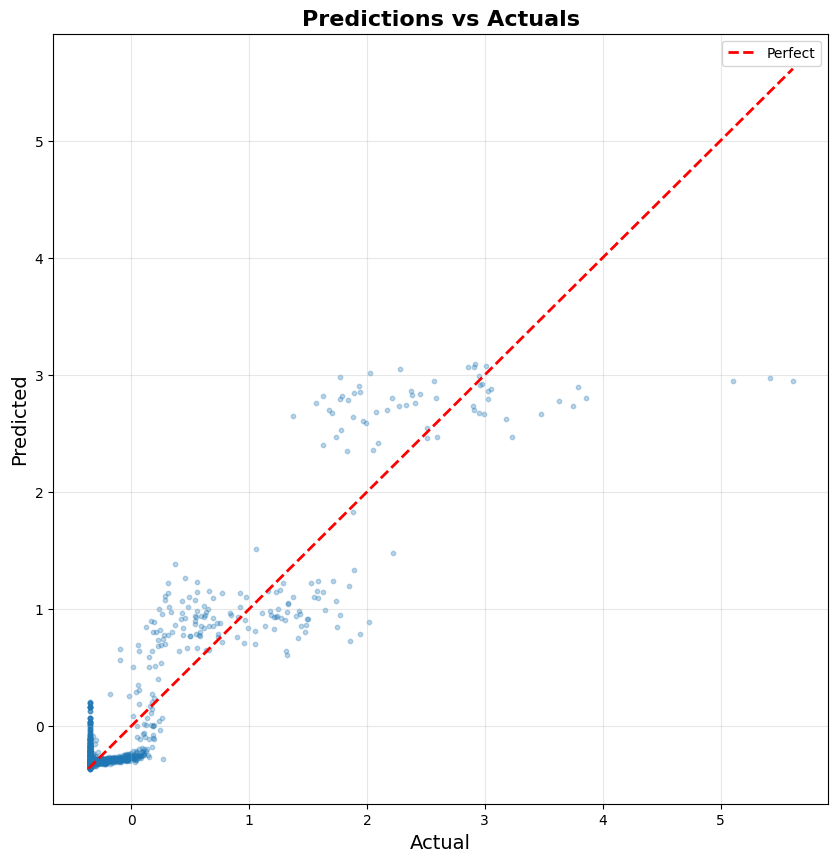

✓ Saved: time_series.png


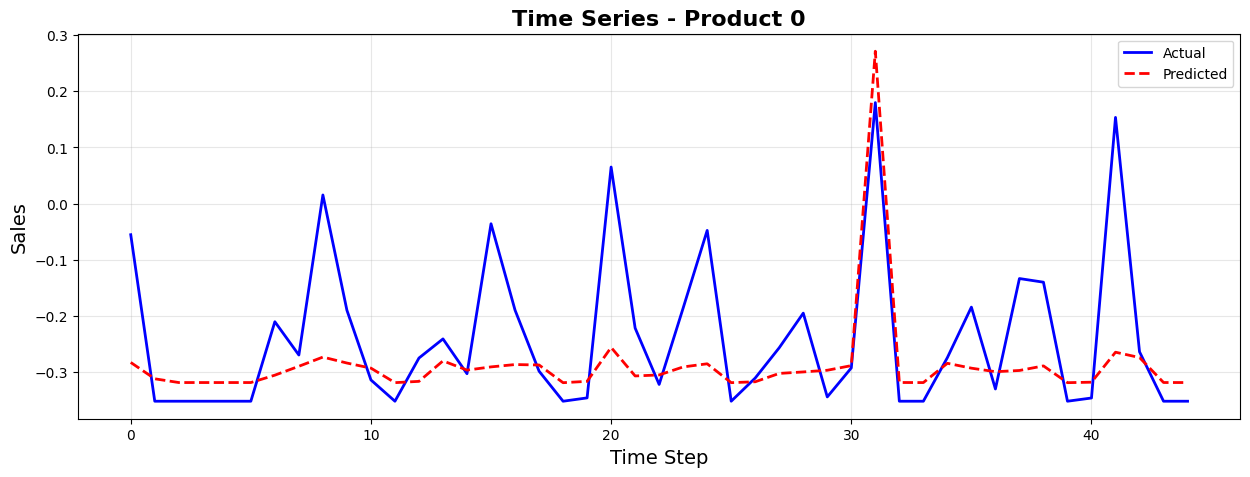


Product    MAE        R²        
------------------------------
0          0.0812     0.2138    
1          0.3836     0.8425    
2          0.2171     -0.8841   
3          0.3309     0.8164    
4          0.5661     0.7360    
5          0.2003     0.7887    
6          0.0507     0.0984    
7          0.0362     -0.0622   
8          0.0575     0.0683    
9          0.1457     -0.0595   

EXAMPLE: Single Prediction

Input shape: torch.Size([40, 4])
Output shape: torch.Size([40])

First 5 products:
Product    Actual       Predicted    Error       
----------------------------------------------
0          -0.06        -0.28        -0.23       
1          1.74         2.47         0.73        
2          0.02         -0.21        -0.23       
3          1.37         2.65         1.28        
4          1.68         2.70         1.03        

✓ Testing complete!


In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.load_state_dict(torch.load(r'C:\Users\KIIT0001\ai_engine\trade_data\best_hybrid_model.pt', map_location=device))
model.eval()

print("✓ Model loaded successfully!")

# ============================================================================
# STEP 2: MAKE PREDICTIONS ON TEST SET
# ============================================================================

predictions = []
actuals = []

print(f"\nMaking predictions on {len(test_snapshots)} test snapshots...")

with torch.no_grad():
    for snap in test_snapshots:
        x = torch.tensor(snap.x, dtype=torch.float).to(device)
        edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
        edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
        y = torch.tensor(snap.y, dtype=torch.float).to(device)
        
        # Predict
        pred = model(x, edge_index, edge_attr)
        
        # Store
        predictions.append(pred.cpu().numpy())
        actuals.append(y.cpu().numpy())

print("✓ Predictions complete!")

# ============================================================================
# STEP 3: CALCULATE METRICS
# ============================================================================

# Flatten all predictions and actuals
preds_flat = np.concatenate(predictions)
actuals_flat = np.concatenate(actuals)

# Calculate metrics
mae = mean_absolute_error(actuals_flat, preds_flat)
rmse = np.sqrt(np.mean((actuals_flat - preds_flat) ** 2))
r2 = r2_score(actuals_flat, preds_flat)

# MAPE
mask = actuals_flat != 0
mape = np.mean(np.abs((actuals_flat[mask] - preds_flat[mask]) / actuals_flat[mask])) * 100

print("\n" + "="*70)
print("TEST RESULTS (Scaled)")
print("="*70)
print(f"MAE:   {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"R²:    {r2:.4f}")
print(f"MAPE:  {mape:.2f}%")
print("="*70)

# ============================================================================
# STEP 4: VISUALIZE RESULTS
# ============================================================================

# Plot 1: Predictions vs Actuals
plt.figure(figsize=(10, 10))
plt.scatter(actuals_flat, preds_flat, alpha=0.3, s=10)
min_val = min(actuals_flat.min(), preds_flat.min())
max_val = max(actuals_flat.max(), preds_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)
plt.title('Predictions vs Actuals', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('predictions_vs_actuals.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: predictions_vs_actuals.png")
plt.show()

# Plot 2: Time Series for Product 0
product_idx = 0
preds_product = [pred[product_idx] for pred in predictions]
actuals_product = [actual[product_idx] for actual in actuals]

plt.figure(figsize=(15, 5))
plt.plot(actuals_product, 'b-', label='Actual', linewidth=2)
plt.plot(preds_product, 'r--', label='Predicted', linewidth=2)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.title(f'Time Series - Product {product_idx}', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('time_series.png', dpi=300, bbox_inches='tight')
print("✓ Saved: time_series.png")
plt.show()

# ============================================================================
# STEP 5: ANALYZE BY PRODUCT
# ============================================================================

num_products = predictions[0].shape[0]

print(f"\n{'Product':<10} {'MAE':<10} {'R²':<10}")
print("-" * 30)

for i in range(min(10, num_products)):  # Show first 10 products
    preds_prod = np.array([pred[i] for pred in predictions])
    actuals_prod = np.array([actual[i] for actual in actuals])
    
    mae_prod = mean_absolute_error(actuals_prod, preds_prod)
    r2_prod = r2_score(actuals_prod, preds_prod)
    
    print(f"{i:<10} {mae_prod:<10.4f} {r2_prod:<10.4f}")

# ============================================================================
# STEP 6: MAKE A SINGLE PREDICTION (EXAMPLE)
# ============================================================================

print("\n" + "="*70)
print("EXAMPLE: Single Prediction")
print("="*70)

# Take first test snapshot
snap = test_snapshots[0]

x = torch.tensor(snap.x, dtype=torch.float).to(device)
edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None

with torch.no_grad():
    prediction = model(x, edge_index, edge_attr)

print(f"\nInput shape: {x.shape}")  # (40, 4) - 40 products, 4 features each
print(f"Output shape: {prediction.shape}")  # (40,) - one prediction per product

print(f"\nFirst 5 products:")
print(f"{'Product':<10} {'Actual':<12} {'Predicted':<12} {'Error':<12}")
print("-" * 46)
for i in range(5):
    actual = snap.y[i]
    pred = prediction[i].item()
    error = pred - actual
    print(f"{i:<10} {actual:<12.2f} {pred:<12.2f} {error:<12.2f}")

print("\n✓ Testing complete!")